# **ASSIGNMENT 7**: Image Registration

In [454]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### **Helper** Functions
---

In [455]:
def load_image(path: str):
    try:
        img = Image.open(path)
        img.load()
        print("Image loaded successfully!")
        return img
    except FileNotFoundError:
        print("Error: Image not found.")
        return None
    except OSError:
        print("Error: File is not a valid image.")
        return None

In [456]:
def verify_convert(img: Image.Image):
    if img.mode == "L":
        print("Image is already 8-bit grayscale.")
        return img
    else:
        print(f"Image mode is {img.mode}. Converting it to 8-bit grayscale ...")
        return img.convert("L")

In [457]:
def print_image(img: Image.Image, title="Image"):
    plt.figure(figsize=(6, 6))
    if img.mode == "L":  # Grayscale
        plt.imshow(img, cmap="gray")
    else:  # RGB
        plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [458]:
def to_array(img):
    return np.array(img, dtype=np.int32)


In [459]:
def to_image(array):
    arr = np.clip(array, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


In [460]:
def resize_image(img, max_size=600):
    w, h = img.size
    if max(w, h) <= max_size:
        return img
    if w > h:
        new_w = max_size
        new_h = int(h * (max_size / w))
    else:
        new_h = max_size
        new_w = int(w * (max_size / h))
    
    return img.resize((new_w, new_h), Image.LANCZOS)

### **Task-related** Functions
---

In [461]:
def show_points(img, points, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.scatter(points[:, 0], points[:, 1], c='r', s=50)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [462]:
def compute_centroid(points):
    return np.mean(points, axis=0)


In [463]:
def mean_center(points, centroid):
    return points - centroid

In [464]:
def compute_covariance(moving_centered, fixed_centered):
    return moving_centered.T @ fixed_centered

In [465]:
def compute_svd(H):
    U, S, Vt = np.linalg.svd(H)
    return U, S, Vt

In [466]:
def compute_rotation(U, Vt):
    R = Vt.T @ U.T
    return R

In [467]:
def compute_translation(centroid_fixed, centroid_moving, R):
    return centroid_fixed - R @ centroid_moving


In [468]:
def transform_points(points, R, t):
    return (R @ points.T).T + t


In [469]:
def apply_transform_to_image(img, R, t):
    h, w = img.size[1], img.size[0]
    transformed = np.zeros((h, w), dtype=np.uint8)
    
    img_arr = to_array(img)

    for y in range(h):
        for x in range(w):
            new_coords = R @ np.array([x, y]) + t
            nx, ny = int(new_coords[0]), int(new_coords[1])
            
            if 0 <= nx < w and 0 <= ny < h:
                transformed[ny, nx] = img_arr[y, x]

    return to_image(transformed)


---
---

Image loaded successfully!
Image loaded successfully!
Image mode is RGB. Converting it to 8-bit grayscale ...
Image mode is RGB. Converting it to 8-bit grayscale ...


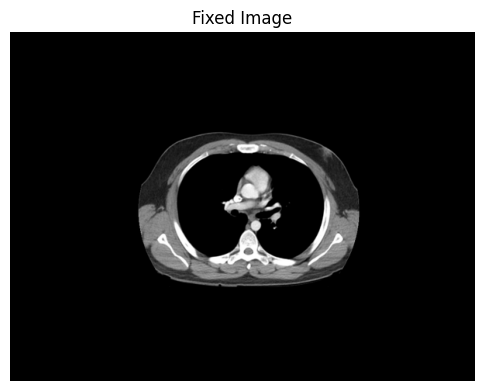

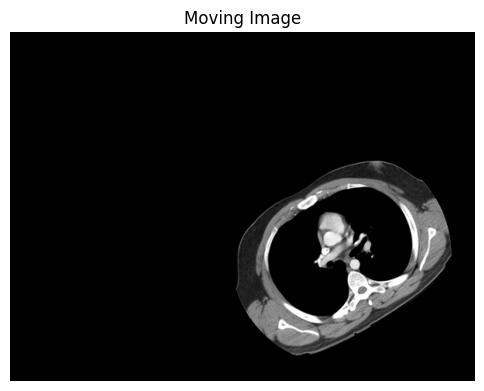

In [ ]:
img_fixed = load_image(r"..\data\img_fixed.png")
img_moving = load_image(r"..\data\img_moving.png")

img_fixed = verify_convert(img_fixed)
img_moving = verify_convert(img_moving)

img_fixed = resize_image(img_fixed)
img_moving = resize_image(img_moving)

print_image(img_fixed, "Fixed Image")
print_image(img_moving, "Moving Image")

In [471]:
# control points
fixed_points = np.array([
    [210, 160],
    [400, 160],
    [310, 205],
    [205, 280],
    [408, 280]
], dtype=np.float64)

moving_points = np.array([
    [305, 280],
    [468,180],
    [415, 265],
    [367, 385],
    [540, 275]
], dtype=np.float64)

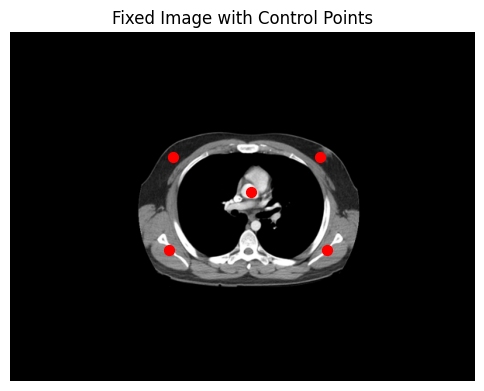

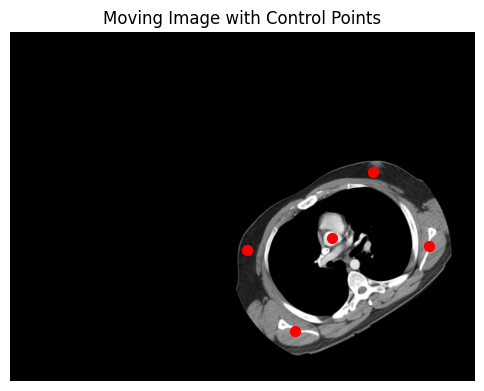

In [472]:
show_points(img_fixed, fixed_points, "Fixed Image with Control Points")
show_points(img_moving, moving_points, "Moving Image with Control Points")

In [473]:
centroid_fixed = compute_centroid(fixed_points)
centroid_moving = compute_centroid(moving_points)

In [474]:
fixed_centered = mean_center(fixed_points, centroid_fixed)
moving_centered = mean_center(moving_points, centroid_moving)

In [475]:
H = compute_covariance(moving_centered, fixed_centered)

In [476]:
U, S, Vt = compute_svd(H)

In [477]:
R = compute_rotation(U, Vt)

In [478]:
t = compute_translation(centroid_fixed, centroid_moving, R)

In [479]:
transformed_points = transform_points(moving_points, R, t)

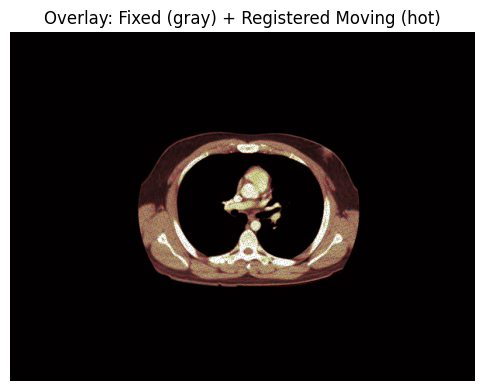

In [480]:
registered_img = apply_transform_to_image(img_moving, R, t)

plt.figure(figsize=(6, 6))
plt.imshow(img_fixed, cmap="gray")
plt.imshow(registered_img, cmap="hot", alpha=0.3)
plt.title("Overlay: Fixed (gray) + Registered Moving (hot)")
plt.axis("off")
plt.show()


### **Verification**

---

In [481]:
transformed_points = transform_points(moving_points, R, t)


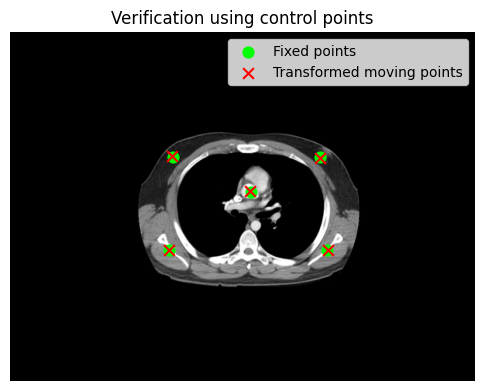

In [482]:
plt.figure(figsize=(6, 6))
plt.imshow(img_fixed, cmap="gray")

plt.scatter(fixed_points[:,0], fixed_points[:,1],
            c='lime', s=60, label='Fixed points')

plt.scatter(transformed_points[:,0], transformed_points[:,1],
            c='red', marker='x', s=60, label='Transformed moving points')

plt.legend()
plt.title("Verification using control points")
plt.axis("off")
plt.show()